In [1]:
#Explorative Data Analysis; Task 2


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

In [2]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})
 

In [3]:
df = pd.read_csv("churn-bigml-20.csv")
 

In [4]:
print("=" * 60)
print("1. DATASET OVERVIEW")
print("=" * 60)
print(f"Shape          : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Memory usage   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("\nColumn dtypes:")
print(df.dtypes.to_string())
print("\nFirst 5 rows:")
print(df.head().to_string())

1. DATASET OVERVIEW
Shape          : 667 rows × 20 columns
Memory usage   : 184.1 KB

Column dtypes:
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool

First 5 rows:
  State  Account length  Area code International plan Voice mail plan  Number vmail messages  Total day minutes  Total day calls  Total day charge  Total eve minutes  Total eve calls  Total eve charge  To

In [6]:
#Checking for missing values

print("\n" + "=" * 60)
print("2. MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else " No missing values found.")


2. MISSING VALUES
 No missing values found.


In [7]:
print("\n" + "=" * 60)
print("3. SUMMARY STATISTICS — Numerical Features")
print("=" * 60)
 


3. SUMMARY STATISTICS — Numerical Features


In [8]:
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include=["object", "bool"]).columns.tolist()
 

In [9]:
stats_df = pd.DataFrame({
    "Mean"   : df[num_cols].mean(),
    "Median" : df[num_cols].median(),
    "Mode"   : df[num_cols].mode().iloc[0],
    "Std Dev": df[num_cols].std(),
    "Min"    : df[num_cols].min(),
    "Max"    : df[num_cols].max(),
}).round(3)
 
print(stats_df.to_string())
 
print("\n--- Categorical / Boolean Features ---")
for col in cat_cols:
    vc = df[col].value_counts()
    print(f"\n{col}:\n{vc.to_string()}")
 

                           Mean  Median    Mode  Std Dev     Min     Max
Account length          102.841  102.00   95.00   40.819    1.00  232.00
Area code               436.157  415.00  415.00   41.783  408.00  510.00
Number vmail messages     8.408    0.00    0.00   13.994    0.00   51.00
Total day minutes       180.948  178.30  153.50   55.509   25.90  334.30
Total day calls         100.937  101.00  102.00   20.397   30.00  165.00
Total day charge         30.762   30.31   26.10    9.436    4.40   56.83
Total eve minutes       203.355  203.70  180.50   49.719   48.10  361.80
Total eve calls         100.477  101.00  101.00   18.948   37.00  168.00
Total eve charge         17.285   17.31   18.33    4.226    4.09   30.75
Total night minutes     199.685  201.60  188.20   49.760   23.20  367.70
Total night calls       100.114  100.00   86.00   20.173   42.00  175.00
Total night charge        8.986    9.07    9.45    2.239    1.04   16.55
Total intl minutes       10.238   10.50   11.30    

In [10]:
# Churn Distribution

churn_counts = df["Churn"].value_counts()
churn_pct    = df["Churn"].value_counts(normalize=True) * 100
print("\n" + "=" * 60)
print("4. CHURN DISTRIBUTION")
print("=" * 60)
print(pd.DataFrame({"Count": churn_counts, "Percent (%)": churn_pct.round(2)}).to_string())


4. CHURN DISTRIBUTION
       Count  Percent (%)
Churn                    
False    572        85.76
True      95        14.24


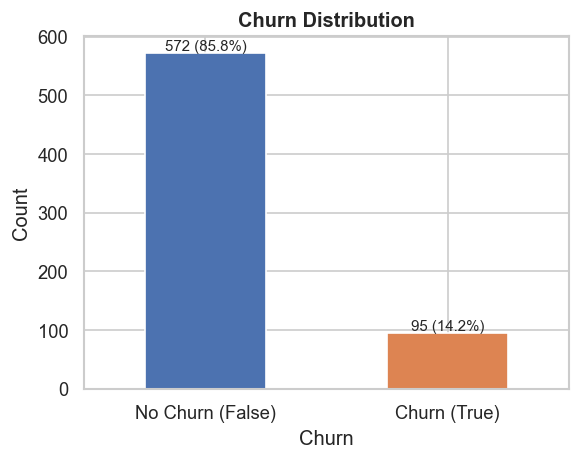

Saved → churn_distribution.png


In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
churn_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"], edgecolor="white")
ax.set_title("Churn Distribution", fontweight="bold")
ax.set_xlabel("Churn")
ax.set_ylabel("Count")
ax.set_xticklabels(["No Churn (False)", "Churn (True)"], rotation=0)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)",
                (p.get_x() + p.get_width() / 2, p.get_height() + 4),
                ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("churn_distribution.png")
plt.show()
print("Saved → churn_distribution.png")


5. HISTOGRAMS — Numerical Feature Distributions


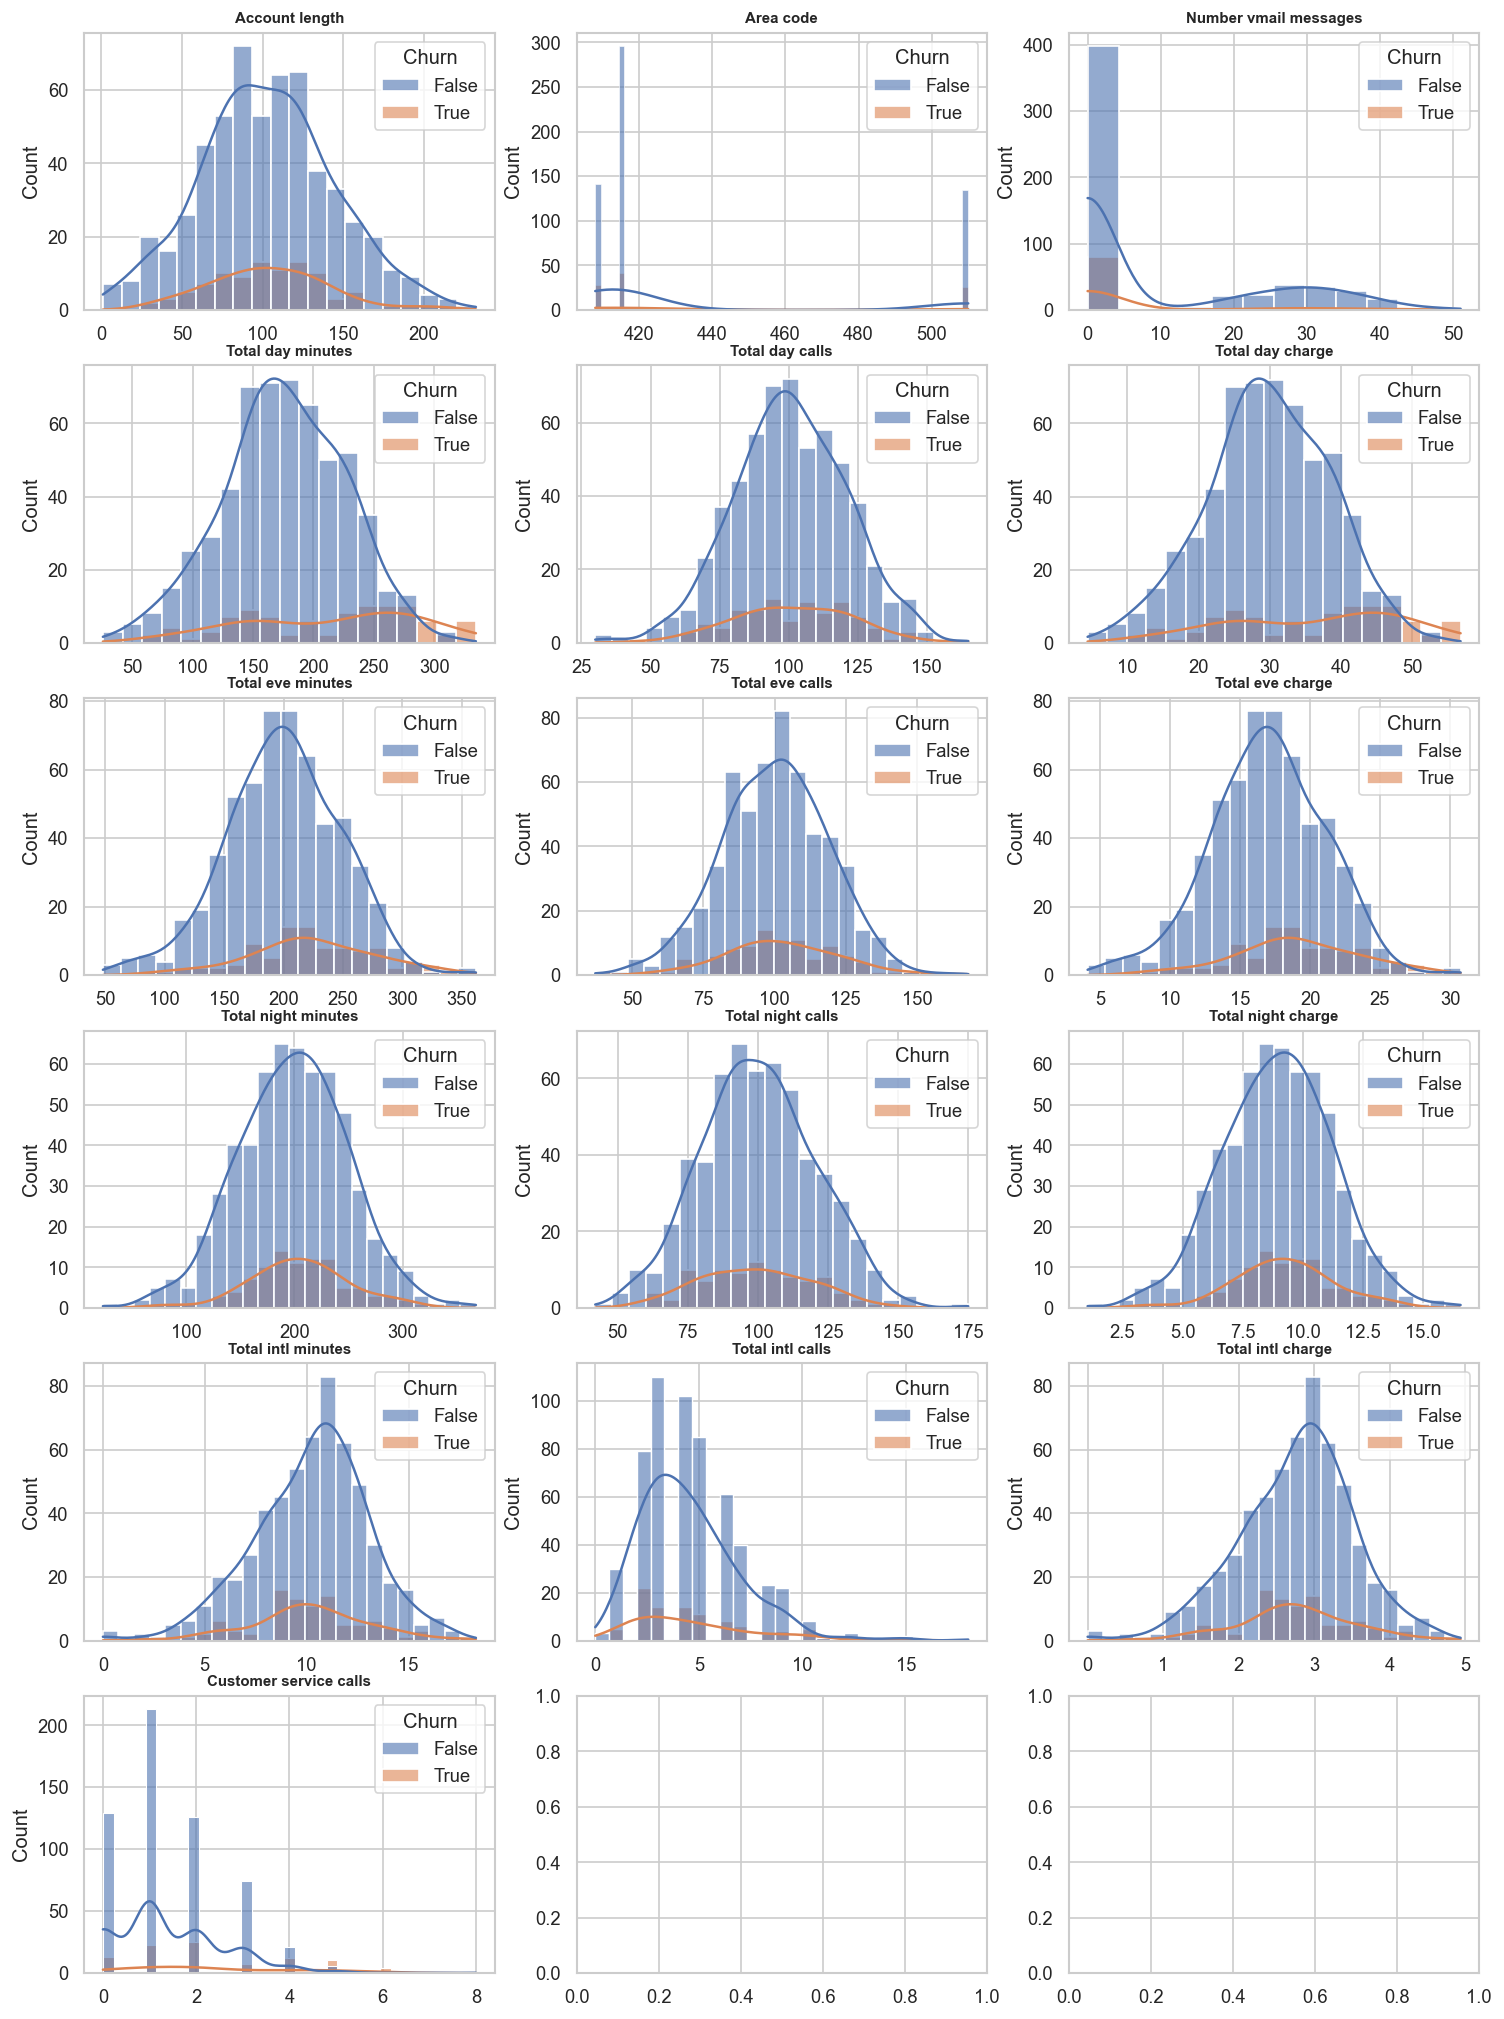

In [13]:
print("\n" + "=" * 60)
print("5. HISTOGRAMS — Numerical Feature Distributions")
print("=" * 60)

n_cols_plot = 3
n_rows_plot = int(np.ceil(len(num_cols) / n_cols_plot))
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(15, n_rows_plot * 3.5))
axes = axes.flatten()
 
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True,
                 palette={False: "#4C72B0", True: "#DD8452"},
                 ax=axes[i], alpha=0.6)
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].set_xlabel("")

In [14]:
#Hide Used Axis

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle("Histograms by Churn Status", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("histograms.png", bbox_inches="tight")
plt.show()
print("Saved → histograms.png")
 

<Figure size 768x576 with 0 Axes>

Saved → histograms.png



6. BOXPLOTS — Numerical Features vs Churn


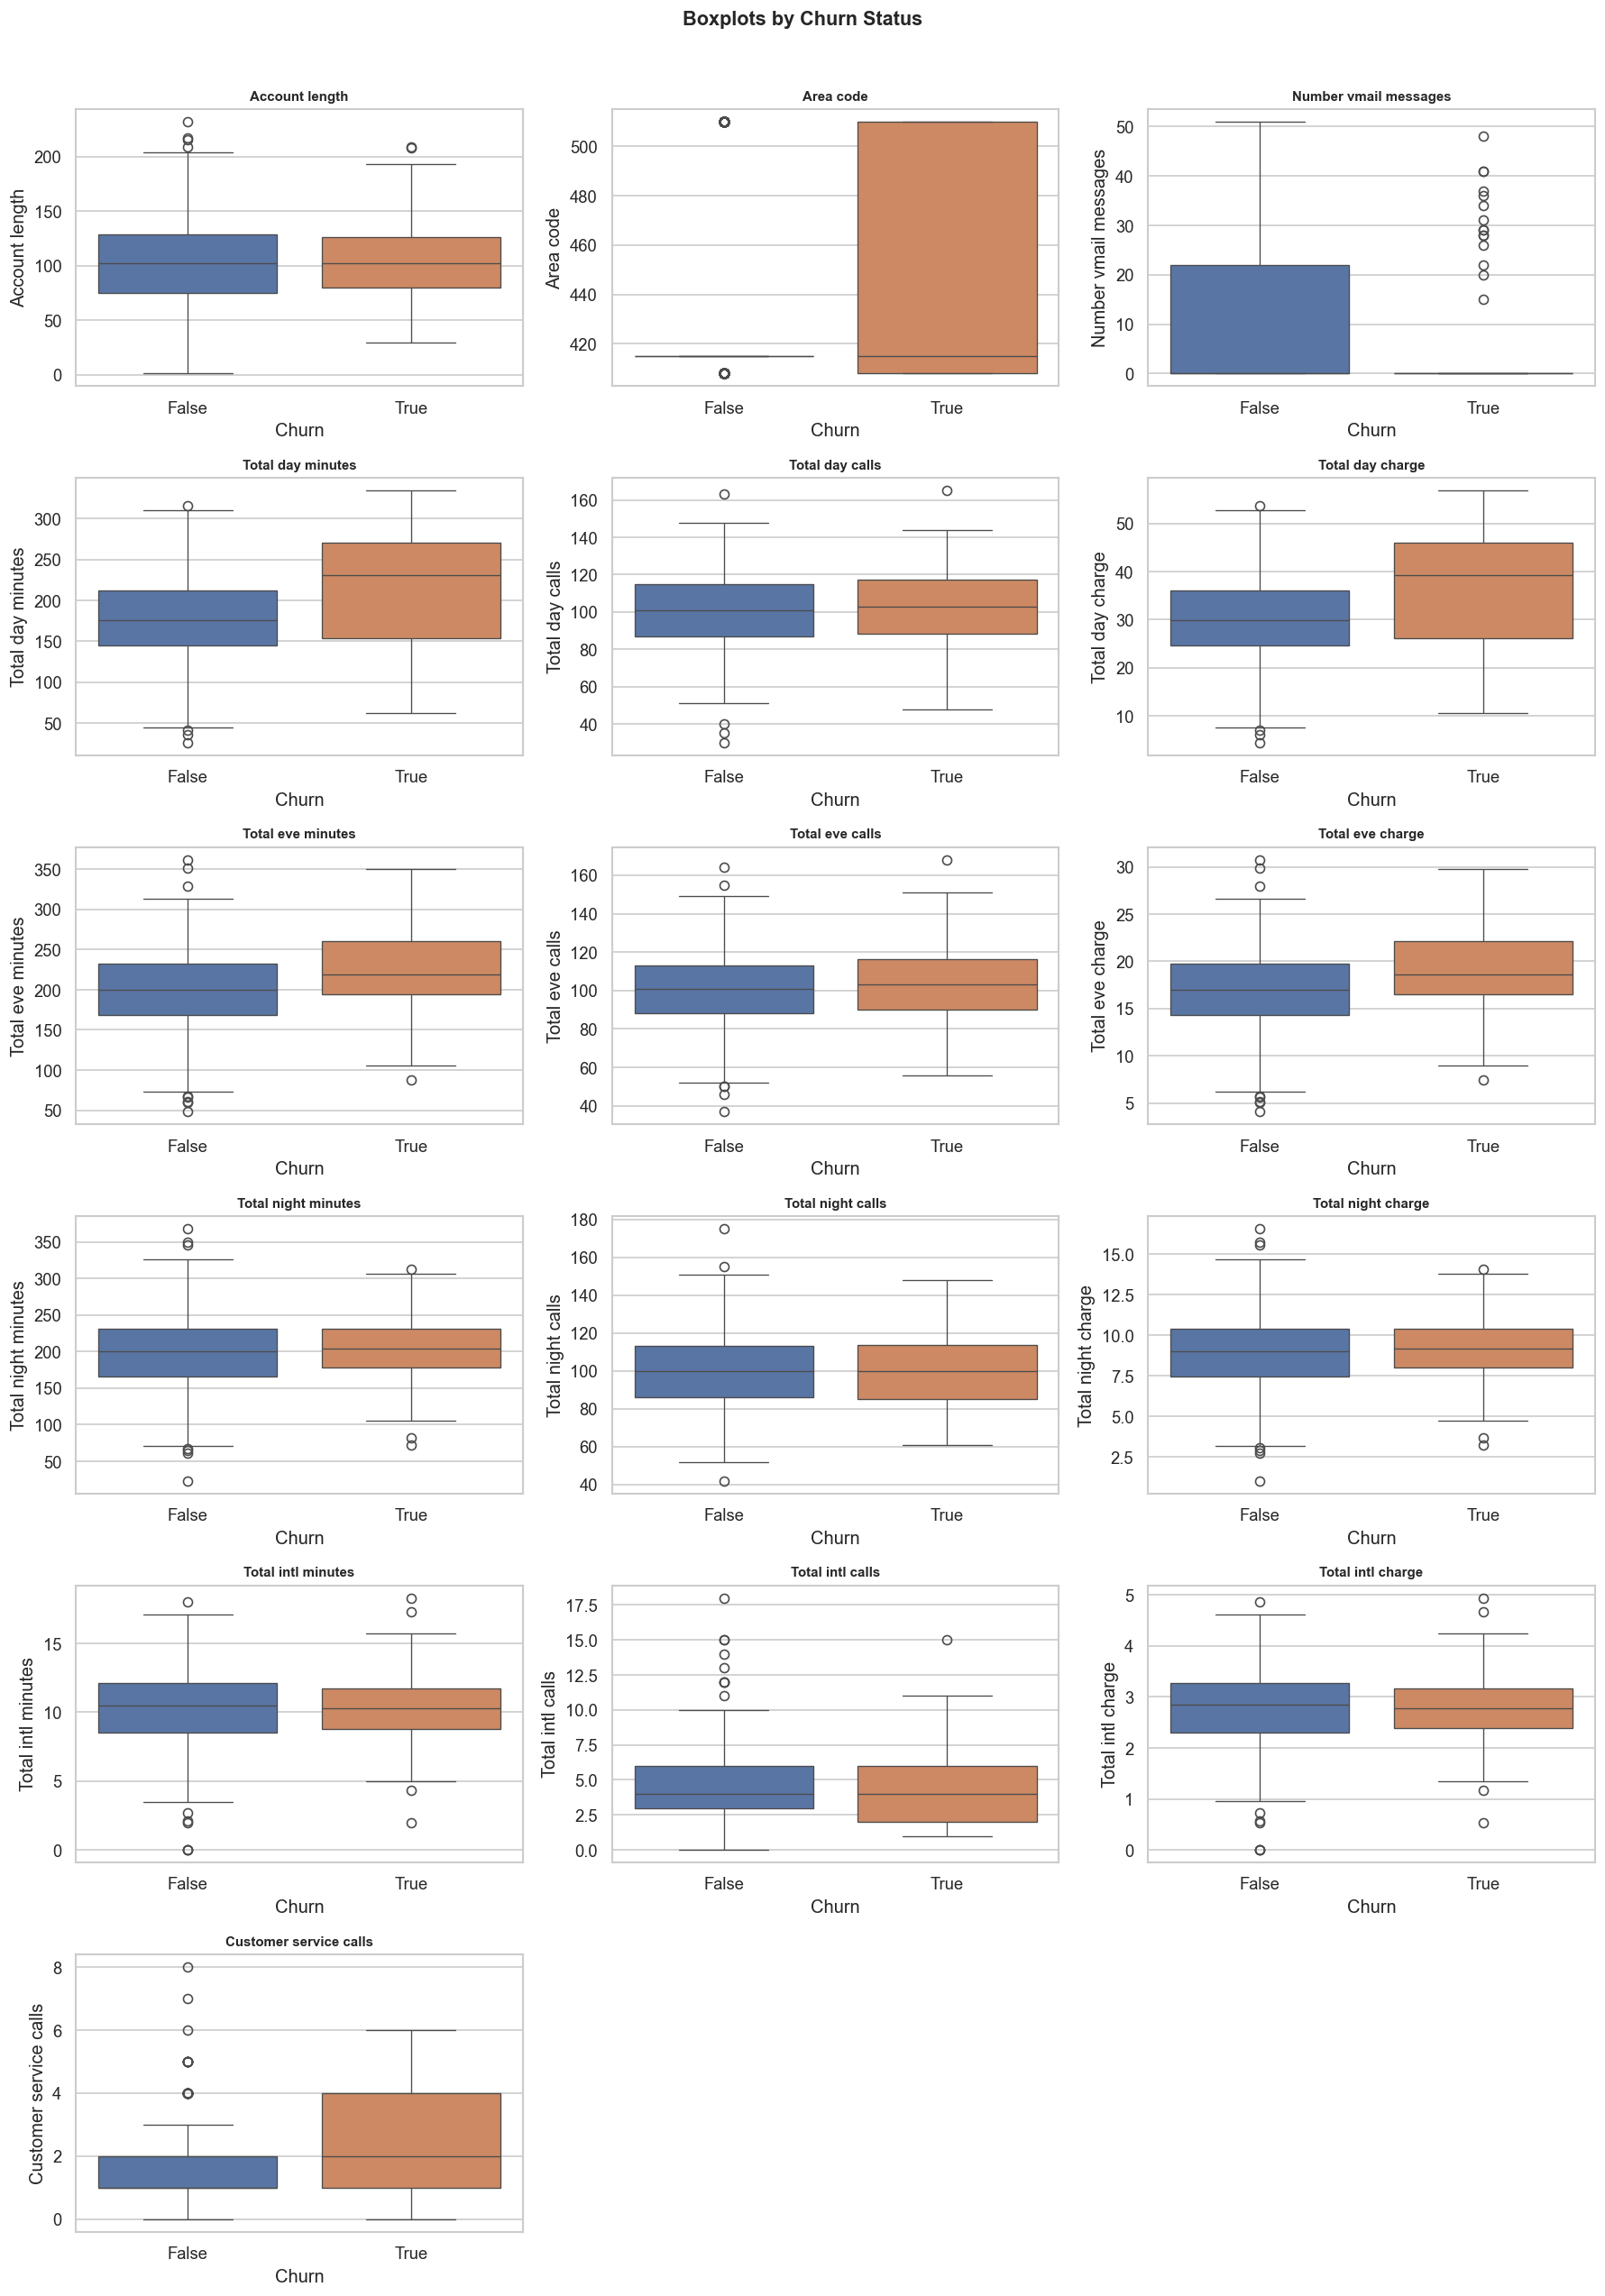

Saved → boxplots.png


In [16]:
#Box PLots

print("\n" + "=" * 60)
print("6. BOXPLOTS — Numerical Features vs Churn")
print("=" * 60)

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(15, n_rows_plot * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="Churn", y=col,
                hue="Churn",
                palette={False: "#4C72B0", True: "#DD8452"},
                legend=False,
                ax=axes[i], linewidth=0.8)
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].set_xlabel("Churn")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots by Churn Status", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("boxplots.png", bbox_inches="tight")
plt.show()
print("Saved → boxplots.png")


7. CORRELATION MATRIX — Numerical Features
                        Account length  Area code  Number vmail messages  Total day minutes  Total day calls  Total day charge  Total eve minutes  Total eve calls  Total eve charge  Total night minutes  Total night calls  Total night charge  Total intl minutes  Total intl calls  Total intl charge  Customer service calls
Account length                    1.00      -0.03                  -0.01               0.02             0.04              0.02               0.03             0.02              0.03                -0.01               0.03               -0.01                0.00              0.03               0.00                   -0.03
Area code                        -0.03       1.00                  -0.01               0.05            -0.01              0.05               0.02             0.02              0.02                -0.02               0.04               -0.02               -0.04             -0.01              -0.04               

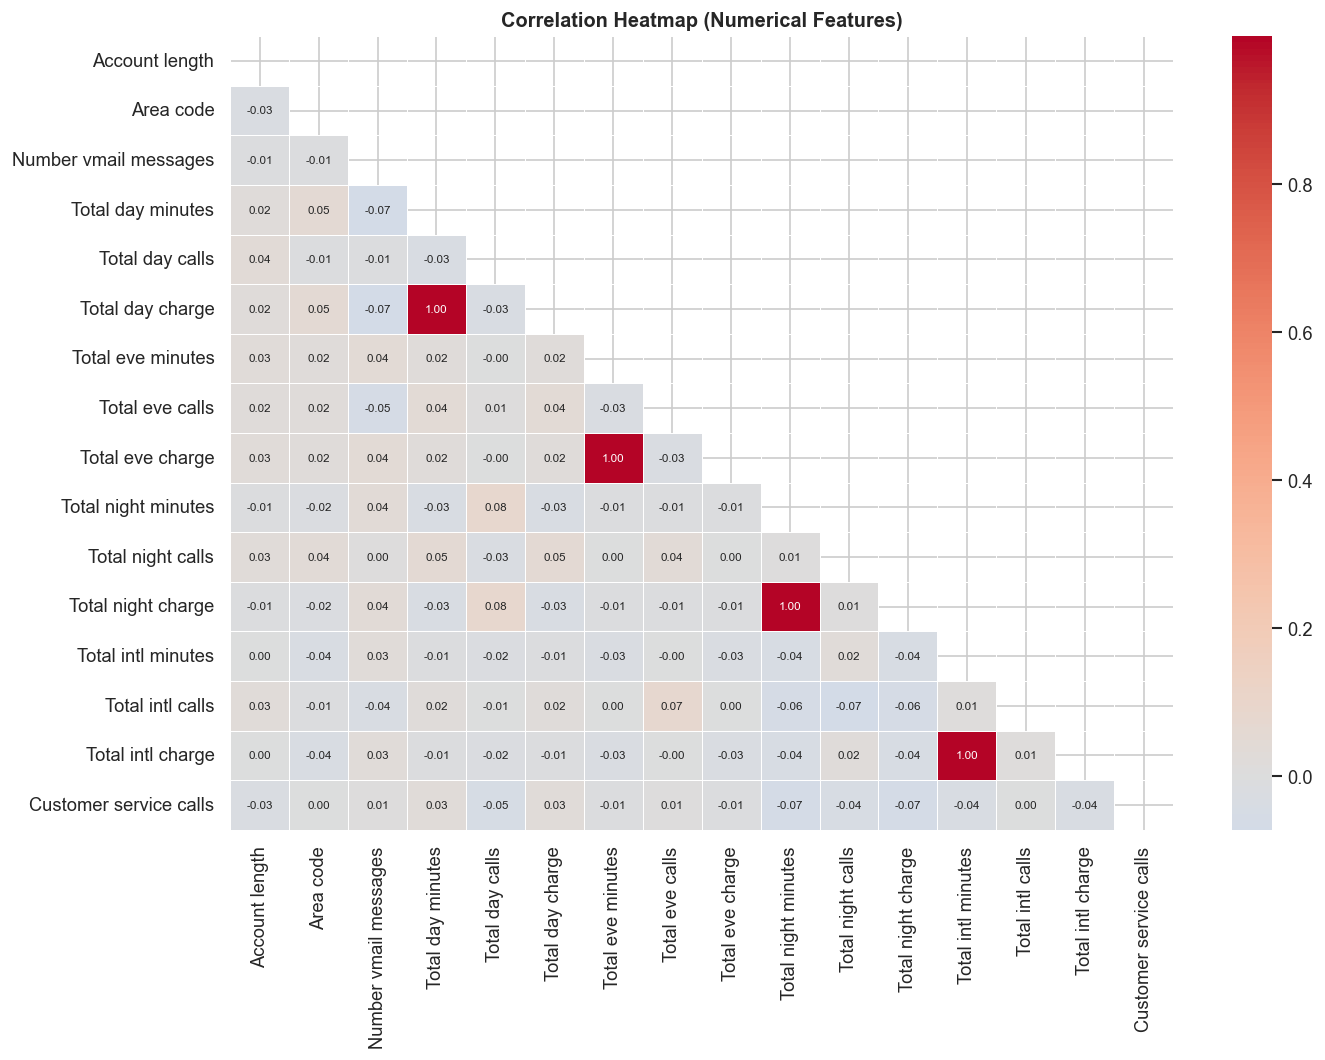

Saved → correlation_heatmap.png


In [17]:
#Correlation Heatmap

print("\n" + "=" * 60)
print("7. CORRELATION MATRIX — Numerical Features")
print("=" * 60)
 
corr = df[num_cols].corr()
print(corr.round(2).to_string())
 
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, ax=ax,
            annot_kws={"size": 7})
ax.set_title("Correlation Heatmap (Numerical Features)", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()
print("Saved → correlation_heatmap.png")

In [18]:
# Top correlations (excluding self-correlations & perfect pairs)

print("\n--- Top Positive Correlations ---")
corr_pairs = (corr.where(~mask).stack()
              .reset_index()
              .rename(columns={"level_0": "Feature A", "level_1": "Feature B", 0: "Correlation"}))
print(corr_pairs.sort_values("Correlation", ascending=False).head(10).to_string(index=False))
 
print("\n--- Top Negative Correlations ---")
print(corr_pairs.sort_values("Correlation").head(5).to_string(index=False))
 


--- Top Positive Correlations ---
          Feature A           Feature B  Correlation
   Total day charge   Total day minutes     1.000000
   Total eve charge   Total eve minutes     1.000000
 Total night charge Total night minutes     0.999999
  Total intl charge  Total intl minutes     0.999993
Total night minutes     Total day calls     0.079536
 Total night charge     Total day calls     0.079529
   Total intl calls     Total eve calls     0.074829
  Total night calls   Total day minutes     0.052761
  Total night calls    Total day charge     0.052748
  Total day minutes           Area code     0.051507

--- Top Negative Correlations ---
             Feature A             Feature B  Correlation
      Total intl calls     Total night calls    -0.072354
      Total day charge Number vmail messages    -0.069187
     Total day minutes Number vmail messages    -0.069172
Customer service calls    Total night charge    -0.067624
Customer service calls   Total night minutes    -0.067602


8. SCATTER PLOTS — Key Feature Pairs


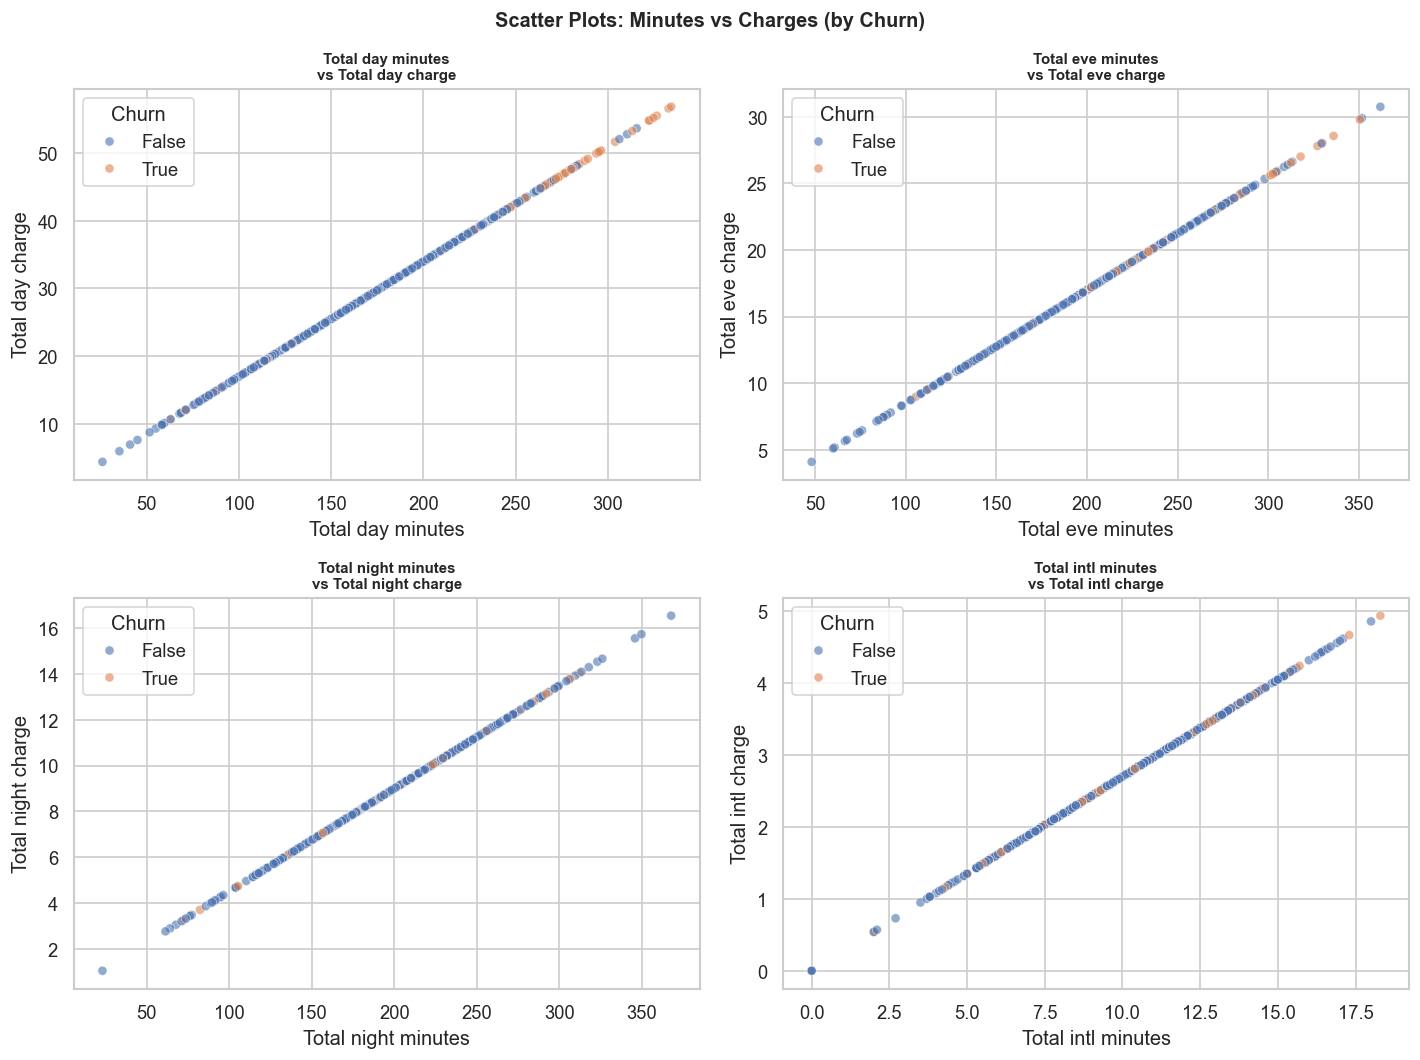

Saved → scatter_plots.png


In [20]:
print("\n" + "=" * 60)
print("8. SCATTER PLOTS — Key Feature Pairs")
print("=" * 60)

scatter_pairs = [
    ("Total day minutes",  "Total day charge"),
    ("Total eve minutes",  "Total eve charge"),
    ("Total night minutes","Total night charge"),
    ("Total intl minutes", "Total intl charge"),
]
 
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
 
for i, (x_col, y_col) in enumerate(scatter_pairs):
    sns.scatterplot(data=df, x=x_col, y=y_col, hue="Churn",
                    palette={False: "#4C72B0", True: "#DD8452"},
                    alpha=0.6, s=30, ax=axes[i])
    axes[i].set_title(f"{x_col}\nvs {y_col}", fontsize=9, fontweight="bold")
 
plt.suptitle("Scatter Plots: Minutes vs Charges (by Churn)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("scatter_plots.png")
plt.show()
print("Saved → scatter_plots.png")


9. CATEGORICAL FEATURES vs CHURN


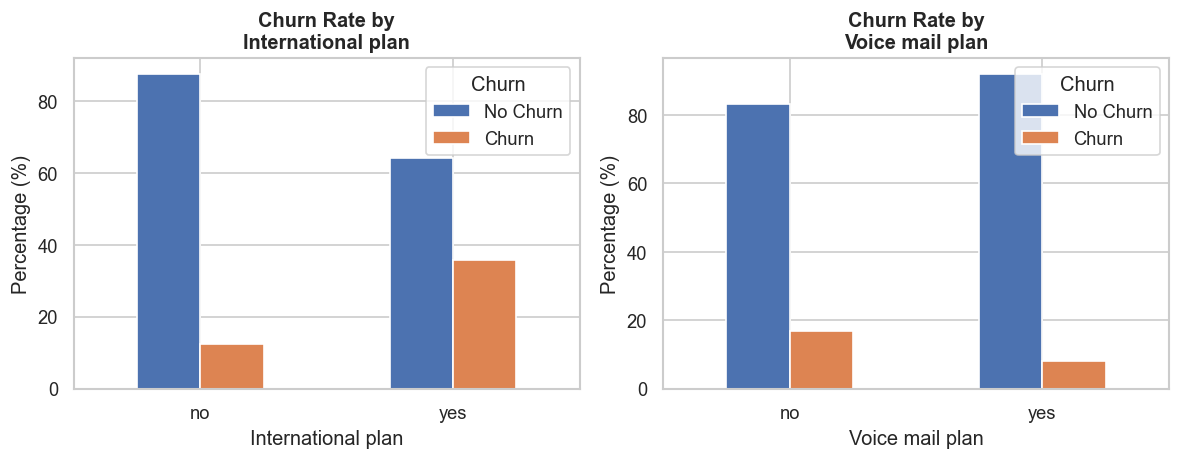

Saved → categorical_churn.png


In [21]:
#Categorical Feature Analysis

print("\n" + "=" * 60)
print("9. CATEGORICAL FEATURES vs CHURN")
print("=" * 60)
 
cat_binary = ["International plan", "Voice mail plan"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
 
for i, col in enumerate(cat_binary):
    ct = pd.crosstab(df[col], df["Churn"], normalize="index") * 100
    ct.plot(kind="bar", ax=axes[i], color=["#4C72B0", "#DD8452"],
            edgecolor="white")
    axes[i].set_title(f"Churn Rate by\n{col}", fontweight="bold")
    axes[i].set_ylabel("Percentage (%)")
    axes[i].set_xlabel(col)
    axes[i].set_xticklabels(ct.index, rotation=0)
    axes[i].legend(["No Churn", "Churn"], title="Churn")
 
plt.tight_layout()
plt.savefig("categorical_churn.png")
plt.show()
print("Saved → categorical_churn.png")
 


--- Customer Service Calls vs Churn ---
Churn                    False  True 
Customer service calls               
0                        90.85   9.15
1                        90.25   9.75
2                        83.44  16.56
3                        91.36   8.64
4                        63.64  36.36
5                        35.29  64.71
6                        20.00  80.00
7                       100.00    NaN
8                       100.00    NaN


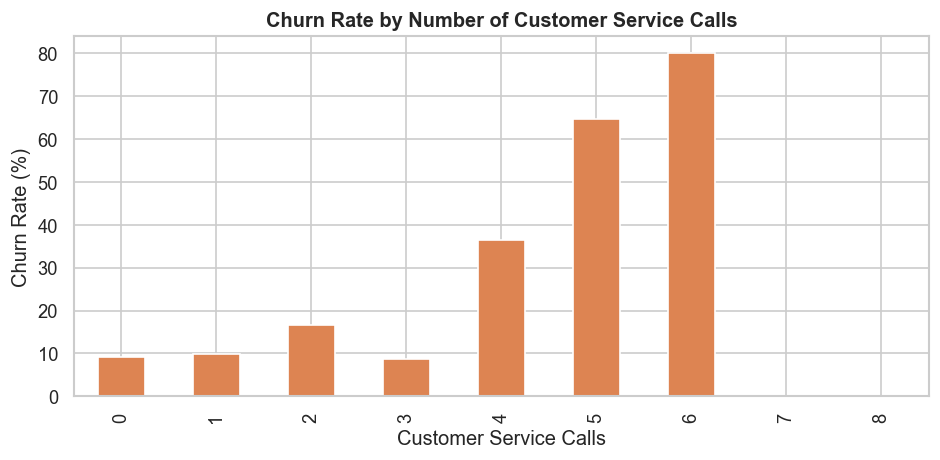

Saved → service_calls_churn.png


In [22]:
print("\n--- Customer Service Calls vs Churn ---")
cs_churn = df.groupby("Customer service calls")["Churn"].value_counts(normalize=True).unstack() * 100
print(cs_churn.round(2).to_string())
 
fig, ax = plt.subplots(figsize=(8, 4))
cs_churn[True].plot(kind="bar", ax=ax, color="#DD8452", edgecolor="white")
ax.set_title("Churn Rate by Number of Customer Service Calls", fontweight="bold")
ax.set_xlabel("Customer Service Calls")
ax.set_ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig("service_calls_churn.png")
plt.show()
print("Saved → service_calls_churn.png")
 

In [23]:
#Statistical Test

print("\n" + "=" * 60)
print("10. STATISTICAL SIGNIFICANCE — T-Tests (Churn vs No Churn)")
print("=" * 60)
print(f"{'Feature':<30} {'t-stat':>10} {'p-value':>12}  {'Significant?':>12}")
print("-" * 70)
for col in num_cols:
    churned     = df[df["Churn"] == True][col]
    not_churned = df[df["Churn"] == False][col]
    t_stat, p_val = stats.ttest_ind(churned, not_churned, equal_var=False)
    sig = "✓ YES" if p_val < 0.05 else "  NO"
    print(f"{col:<30} {t_stat:>10.3f} {p_val:>12.4f}  {sig:>12}")
 
print("\n" + "=" * 60)
print("EDA COMPLETE — all plots saved to working directory.")
print("=" * 60)


10. STATISTICAL SIGNIFICANCE — T-Tests (Churn vs No Churn)
Feature                            t-stat      p-value  Significant?
----------------------------------------------------------------------
Account length                      0.348       0.7286            NO
Area code                           0.671       0.5035            NO
Number vmail messages              -3.025       0.0029         ✓ YES
Total day minutes                   5.083       0.0000         ✓ YES
Total day calls                     0.484       0.6292            NO
Total day charge                    5.083       0.0000         ✓ YES
Total eve minutes                   4.260       0.0000         ✓ YES
Total eve calls                     1.366       0.1744            NO
Total eve charge                    4.260       0.0000         ✓ YES
Total night minutes                 1.191       0.2357            NO
Total night calls                  -0.468       0.6407            NO
Total night charge                  1.192